## Title : Hotel Booking Cancellation Prediction using Machine Learning

### Problem Statement : Predict hotel booking cancellations using machine learning to help reduce revenue loss and improve planning.

### The objective of this project is:
##### Analyze booking patterns
##### Identify factors affecting cancellations
##### Build ML models to predict cancellation
##### Compare model performance
##### Select the best model

## Step 1 : Import Libraries

In [1]:
! pip install xgboost

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Step 2 : Read Dataset

In [3]:
df = pd.read_csv("hotel_booking.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## Step 3 : Dataset Overview

In [5]:
df.shape

(119390, 36)

In [6]:
df.size

4298040

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [9]:
df.describe(exclude='object').T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [10]:
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## Step 4 : Data Preprocessing

#### Step 4.1 : Handling Missing Values

In [11]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_year                      0
lead_time                              0
is_canceled                            0
hotel                                  0
stays_in_weekend_nights                0
stays_in_week_nights                   0
arrival_date_day_of_month              0
arrival_date_month                     0
babies                                 0
meal                                   0
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
adults                                 0
arrival_date_week_number               0
reserved_room_type                     0
previous_bookings_not_canceled         0
booking_changes                        0
assigned_room_type                     0
deposit_type    

#### Insights : The dataset contains missing values in four columns.

In [12]:
df['agent'].fillna(0, inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['children'].fillna(df['children'].median(), inplace=True)

In [13]:
df['company'].fillna(0, inplace=True)

### Step 4.2 : Duplicate Value Analysis

In [14]:
df.duplicated().sum()

np.int64(0)

#### Insights : No duplicate records found in the dataset

### Step 4.3 : Outlier Analysis

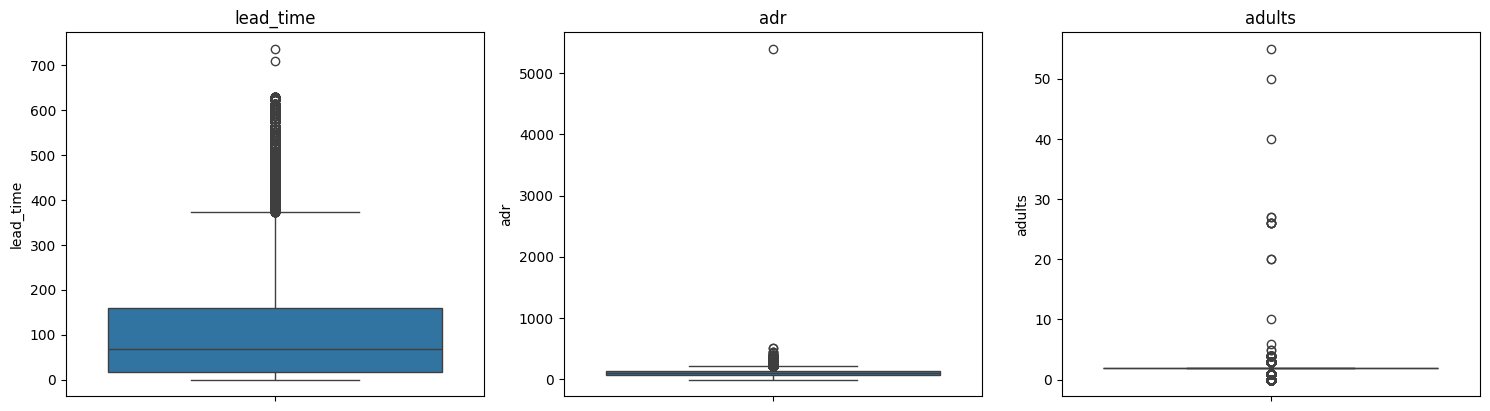

In [15]:
numerical_cols = ['lead_time', 'adr', 'adults']

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Insights : Outliers were observed in several numerical features such as lead_time, adr, adults.

In [16]:
print("Shape before outlier removal:", df.shape)

Shape before outlier removal: (119390, 36)


#### Remove Outliers from ADR

In [17]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['adr'] >= lower) & (df['adr'] <= upper)]

#### Remove Outliers from Adults

In [18]:
Q1 = df['adults'].quantile(0.25)
Q3 = df['adults'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['adults'] >= lower) & (df['adults'] <= upper)]

In [19]:
print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (86795, 36)


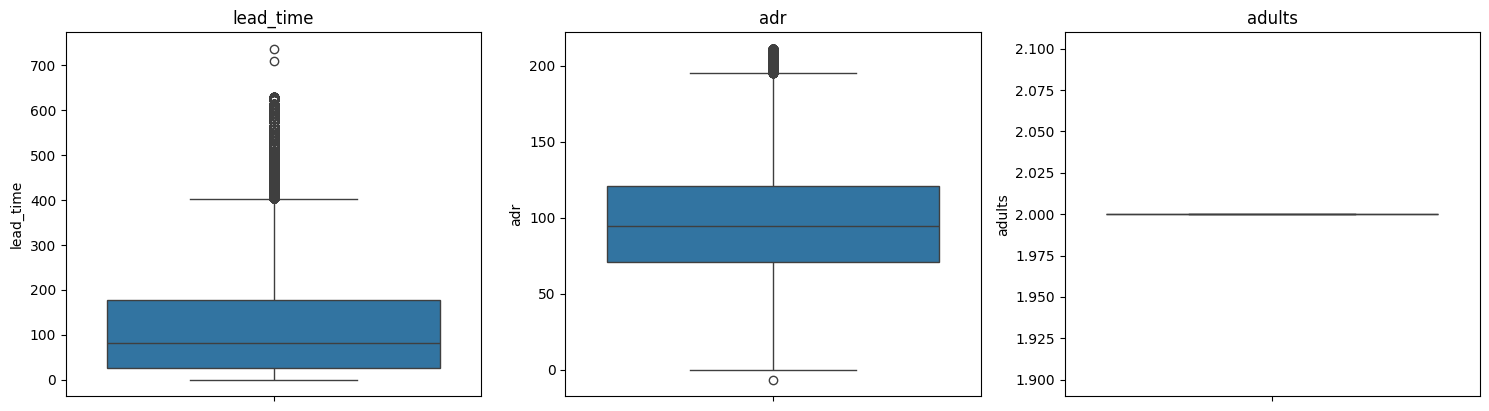

In [20]:
numerical_cols = ['lead_time', 'adr', 'adults']

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(2,3,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

## Step 5 : Exploratory Data Analysis (EDA)

### Step 5.1 : Univariate Analysis

#### What is the distribution of cancelled and non-cancelled bookings?

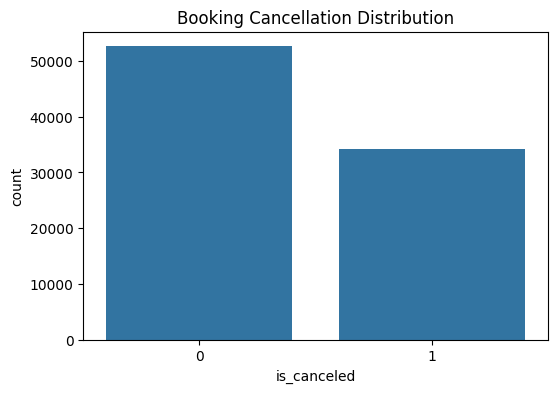

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled',data=df)
plt.title('Booking Cancellation Distribution')
plt.show()

#### Observations : The majority of bookings were not cancelled, while a significant portion of bookings were cancelled.

#### Which hotel type receives the highest number of bookings?

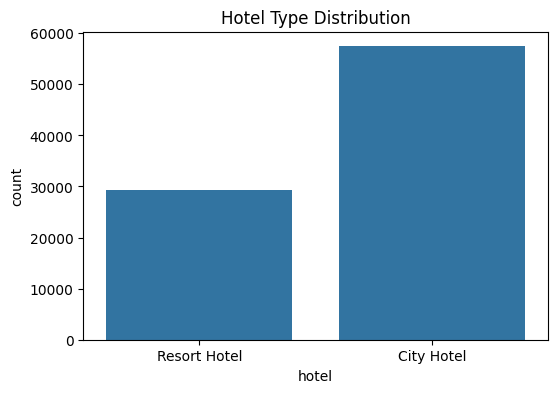

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='hotel',data=df)
plt.title('Hotel Type Distribution')
plt.show()

#### Observations : City Hotels receive more bookings compared to Resort Hotels.

#### How far in advance do customers make hotel bookings?

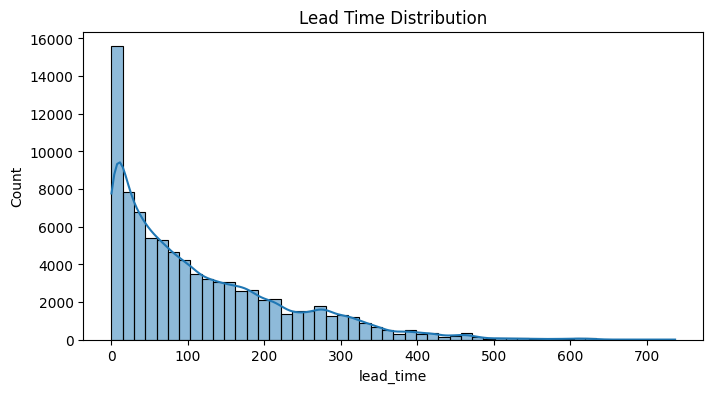

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(df['lead_time'],bins=50,kde=True)
plt.title('Lead Time Distribution')
plt.show()

#### Observations : Most customers book within a moderate lead time range, while some customers book several months in advance.

#### Which market segment contributes the highest number of bookings?

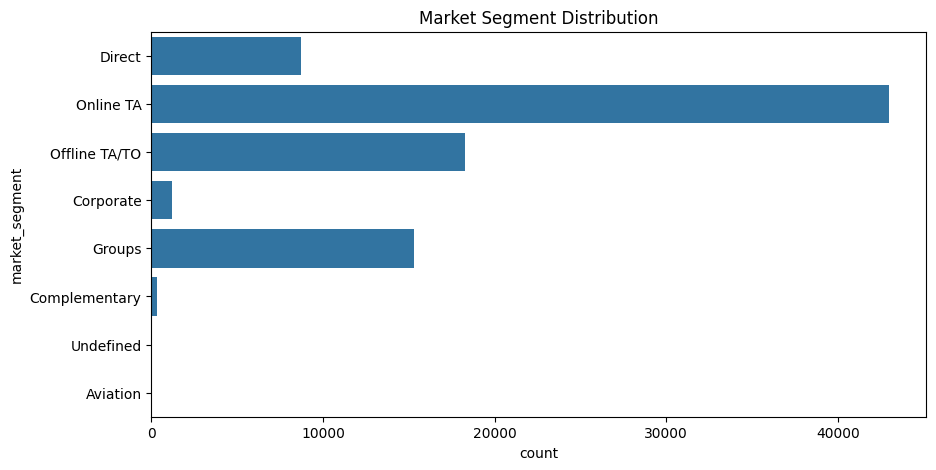

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(y='market_segment',data=df)
plt.title('Market Segment Distribution')
plt.show()

#### Observations : Online Travel Agencies (OTA) contribute the largest share of hotel bookings.

#### Which month receives the highest number of bookings?

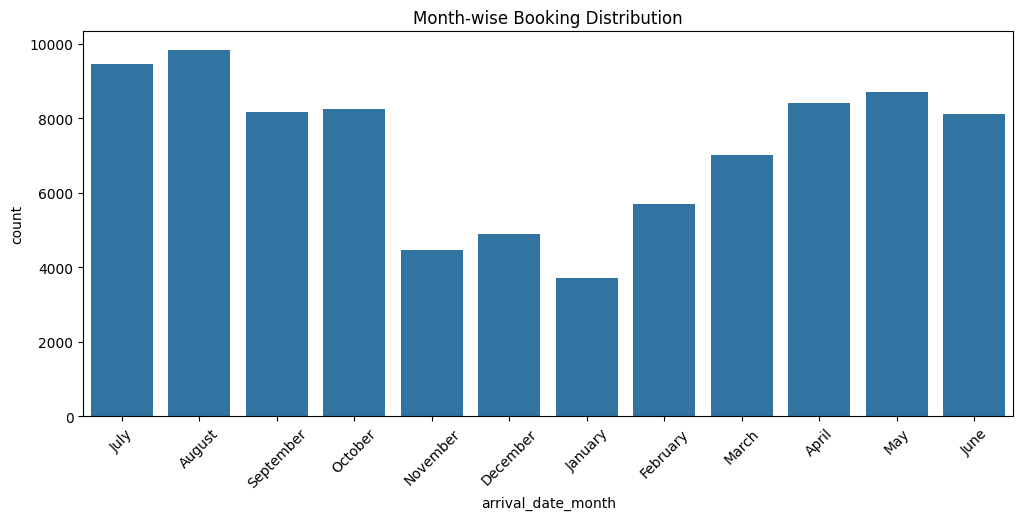

In [25]:
plt.figure(figsize=(12,5))
sns.countplot(x='arrival_date_month',data=df)
plt.xticks(rotation=45)
plt.title('Month-wise Booking Distribution')
plt.show()

#### Observations : Most bookings are made during July and August, whereas January has the fewest bookings.

#### Which type of customers make the most bookings?

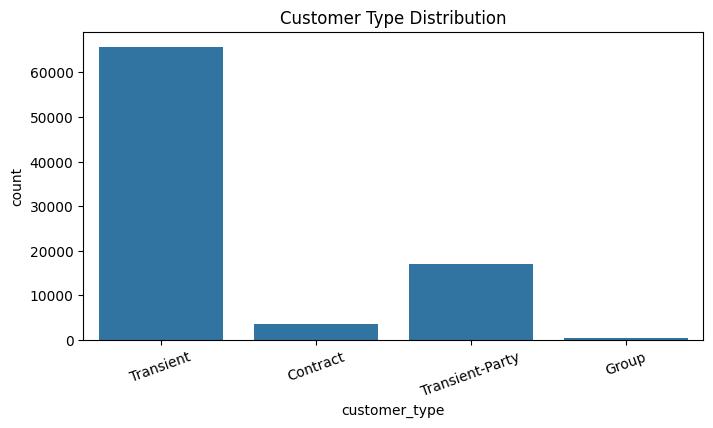

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(x='customer_type',data=df)
plt.xticks(rotation=20)
plt.title('Customer Type Distribution')
plt.show()

#### Observations : Transient customers account for the majority of hotel bookings.

### Step 5.2 : Bivariate Analysis

#### Which hotel type experiences the highest booking cancellation rate?

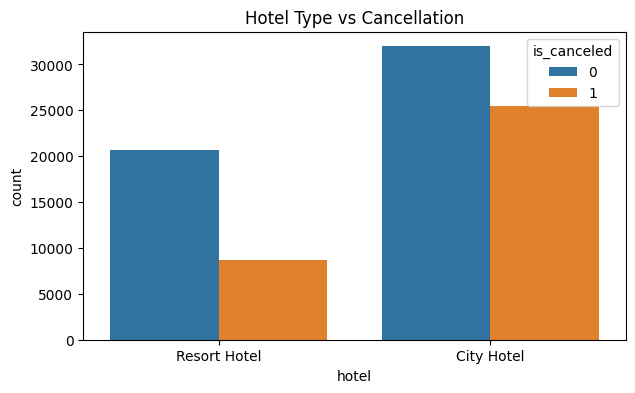

In [27]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df
)

plt.title('Hotel Type vs Cancellation')
plt.show()

#### Observations : City Hotels have more bookings as well as more cancellations than Resort Hotels.

#### Which market segment contributes the highest number of cancellations?

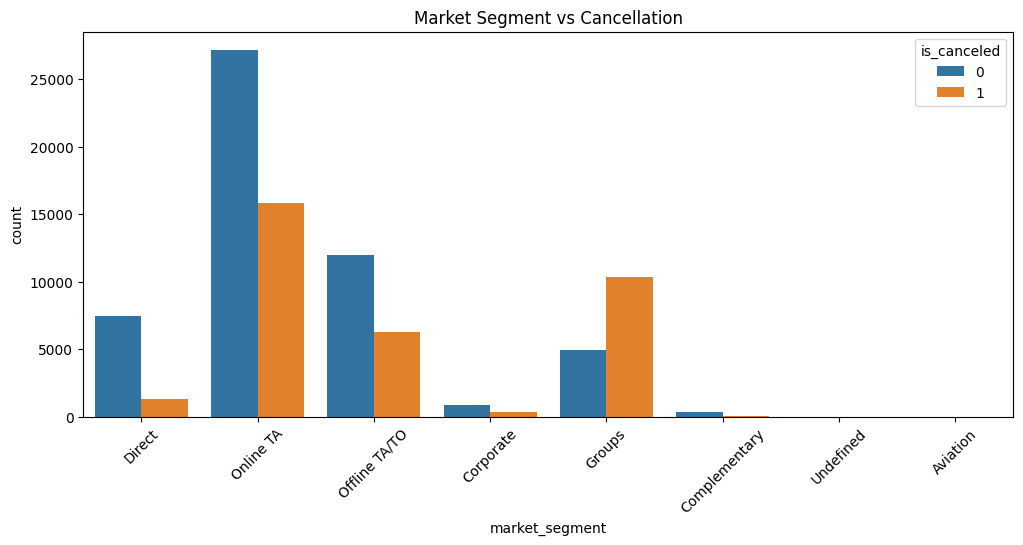

In [28]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='market_segment',
    hue='is_canceled',
    data=df
)

plt.xticks(rotation=45)

plt.title('Market Segment vs Cancellation')
plt.show()

#### Observations : Most cancellations come from the Online TA segment, while Direct and Corporate bookings have comparatively fewer cancellations.

#### Which customer type has the highest cancellation rate?

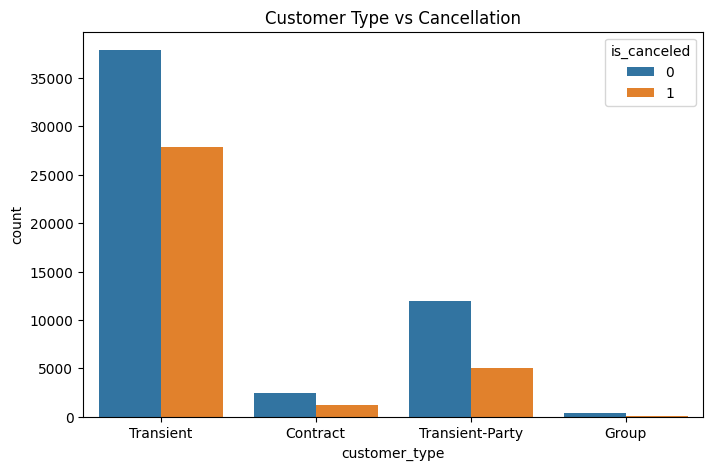

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='customer_type',
    hue='is_canceled',
    data=df
)

plt.title('Customer Type vs Cancellation')
plt.show()

#### Observations : Transient customers are more likely to cancel bookings compared to other customer types.

#### Does the number of special requests influence booking cancellations?

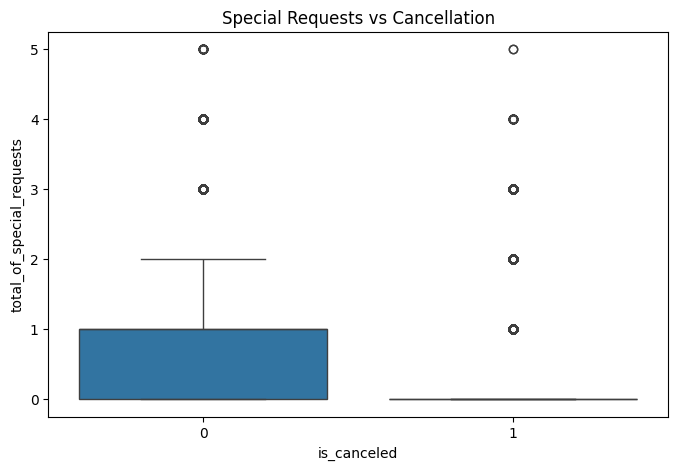

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='total_of_special_requests',
    data=df
)

plt.title('Special Requests vs Cancellation')
plt.show()

#### Observations : Guests who make special requests tend to keep their bookings, while guests with fewer requests are more likely to cancel.

#### Does room price affect booking cancellation behavior?

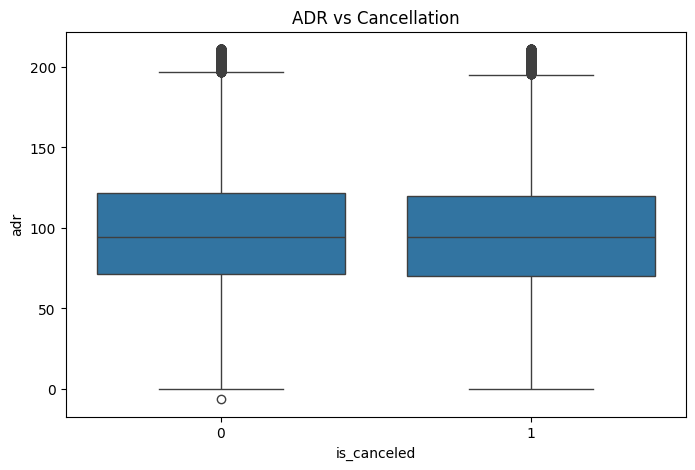

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='adr',
    data=df
)

plt.title('ADR vs Cancellation')
plt.show()

#### Observations : The ADR distribution is similar for both cancelled and non-cancelled bookings. This indicates that room price alone does not significantly influence booking cancellation behavior.

#### Does the deposit type affect booking cancellations?

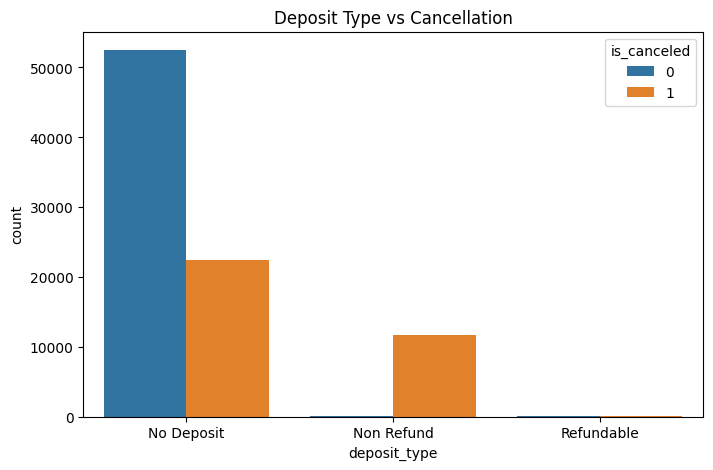

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df
)

plt.title('Deposit Type vs Cancellation')
plt.show()

#### Observations :Bookings with a No Refund deposit type have the highest cancellation rate, while bookings with a No Deposit policy are less likely to be cancelled.

### Step 6 : Feature Engineering and Data Preparation

#### Step 6.1 Remove Unnecessary Columns

df.drop(
    columns=[
        'reservation_status',
        'reservation_status_date'
    ],
    inplace=True
)

#### These columns directly reveal the booking outcome and would cause data leakage. Including them would result in unrealistically high model performance.

### Step 6.3 Feature Engineering

In [33]:
df['total_stay'] = (
    df['stays_in_week_nights']
    +
    df['stays_in_weekend_nights']
)

#### A customer's total length of stay may influence cancellation behavior and provides more meaningful information than separate weekday and weekend stay counts.

### Step 6.4 : Encoding Categorical Variables

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

### Step 6.6 : Separate Features and Target Variable

In [35]:
x = df.drop('is_canceled', axis=1)

y = df['is_canceled']

### Step 6.7 : Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

### Step 6.8 : Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scl = scaler.fit_transform(x_train)

x_test_scl = scaler.transform(x_test)

## Step 7 : Machine Learning Model Training

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

### KNN Algorithm

In [39]:
knn = KNeighborsClassifier(n_neighbors = 3)

knn.fit(x_train_scl,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [40]:
y_pred_knn = knn.predict(x_test_scl)

acc_knn = accuracy_score(y_pred_knn, y_test)
print(f"Accuracy of KNN is :{acc_knn*100:.2f}%\n")

Accuracy of KNN is :98.35%



### Naive Bayes Algorithm

In [41]:
nb = GaussianNB()

nb.fit(x_train_scl,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [42]:
y_pred_nb = nb.predict(x_test_scl)

acc_nb = accuracy_score(y_pred_nb,y_test)
print(f"Accuracy of Naive Bayes is :{acc_nb*100:.2f}%\n")

Accuracy of Naive Bayes is :99.40%



### Logistic Regression

In [43]:
lr = LogisticRegression()

lr.fit(x_train_scl,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
y_pred_lr = lr.predict(x_test_scl)

acc_lr = accuracy_score(y_pred_lr,y_test)
print(f"Accuracy of Logistic Regression is :{acc_lr*100:.2f}%\n")

Accuracy of Logistic Regression is :99.24%



### Decision Tree Algorithm

In [45]:
tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)

tree.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [46]:
y_pred = tree.predict(x_test)

acc_tree = accuracy_score(y_test, y_pred)
print(f"Accuracy of Decision Tree Algorithm is : {acc_tree * 100:.2f}%\n")

Accuracy of Decision Tree Algorithm is : 100.00%



### Random Forest Algorithm

In [47]:
rf = RandomForestClassifier()

rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
y_pred_rf = rf.predict(x_test)

acc_rf = accuracy_score(y_test,y_pred_rf)
print(f"Accuracy of Random Forest Classifier is :{acc_rf*100:.2f}%\n")

Accuracy of Random Forest Classifier is :100.00%



### Ada Boost Classifier

In [49]:
ada = AdaBoostClassifier()

ada.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [50]:
y_pred_ada = ada.predict(x_test)

acc_ada = accuracy_score(y_test,y_pred_ada)
print(f"Accuracy of Ada Boost Classifier is :{acc_ada*100:.2f}%\n")

Accuracy of Ada Boost Classifier is :100.00%



### Gradient Boosting Algorithm

In [51]:
gd = GradientBoostingClassifier()

gd.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [52]:
y_pred_gd = gd.predict(x_test)

acc_gb = accuracy_score(y_test,y_pred_gd)
print(f"Accuracy of Gradient Boosting Classifier is :{acc_gb*100:.2f}%\n")

Accuracy of Gradient Boosting Classifier is :100.00%



In [53]:
results = pd.DataFrame({
    'Model': [
        'KNN',
        'Naive Bayes',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting'
    ],

    'Accuracy (%)': [
        round(acc_knn * 100, 2),
        round(acc_nb * 100, 2),
        round(acc_lr * 100, 2),
        round(acc_tree * 100, 2),
        round(acc_rf * 100, 2),
        round(acc_ada * 100, 2),
        round(acc_gb * 100, 2)
    ]
})

results = results.sort_values(
    by='Accuracy (%)',
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy (%)
0,AdaBoost,100.00
1,Random Forest,100.00
2,Decision Tree,100.00
3,Gradient Boosting,100.00
4,Naive Bayes,99.40
5,Logistic Regression,99.24
6,KNN,98.35


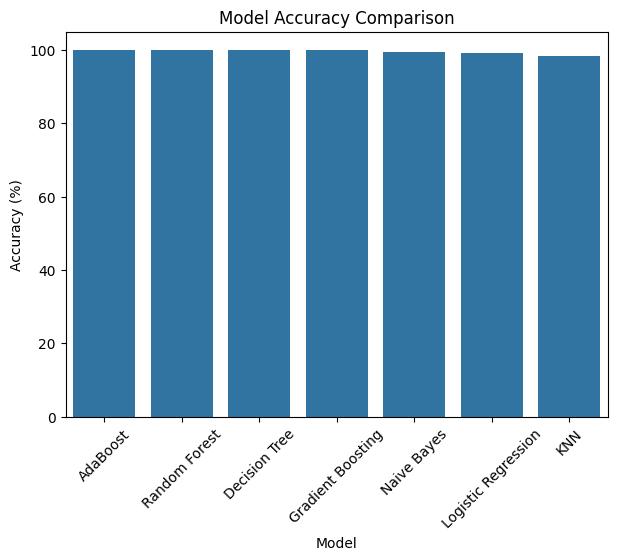

In [54]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Model',
    y='Accuracy (%)',
    data=results
)

plt.xticks(rotation=45)

plt.title('Model Accuracy Comparison')

plt.show()

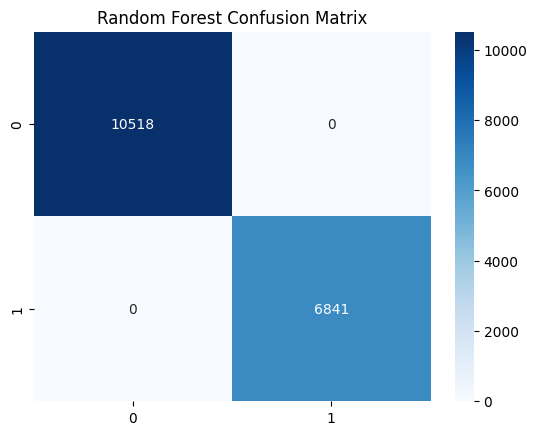

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10518
           1       1.00      1.00      1.00      6841

    accuracy                           1.00     17359
   macro avg       1.00      1.00      1.00     17359
weighted avg       1.00      1.00      1.00     17359



In [57]:
print(x.columns.tolist())

['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card', 'total_stay']


In [58]:
# Select important features only

features = [
    'hotel',
    'lead_time',
    'adults',
    'children',
    'adr',
    'previous_cancellations',
    'deposit_type',
    'customer_type',
    'total_of_special_requests'
]

X_new = df[features]
y_new = df['is_canceled']

In [59]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_final.fit(X_train_new, y_train_new)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
from sklearn.metrics import accuracy_score

y_pred_final = rf_final.predict(X_test_new)

acc_final = accuracy_score(
    y_test_new,
    y_pred_final
)

print(f"Final Random Forest Accuracy : {acc_final*100:.2f}%")

Final Random Forest Accuracy : 81.48%


In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_new,
    y_pred_final
)

print(cm)

[[9200 1318]
 [1897 4944]]


In [63]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_new,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85     10518
           1       0.79      0.72      0.75      6841

    accuracy                           0.81     17359
   macro avg       0.81      0.80      0.80     17359
weighted avg       0.81      0.81      0.81     17359



In [64]:
import joblib

joblib.dump(
    rf_final,
    'hotel_booking_final_model.pkl'
)

print("Final Model Saved Successfully!")

Final Model Saved Successfully!


In [65]:
joblib.dump(
    features,
    'feature_names.pkl'
)

print("Feature Names Saved Successfully!")

Feature Names Saved Successfully!


In [66]:
import joblib

features = joblib.load("feature_names.pkl")

print(features)
print(len(features))

['hotel', 'lead_time', 'adults', 'children', 'adr', 'previous_cancellations', 'deposit_type', 'customer_type', 'total_of_special_requests']
9


In [67]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
.zip
9 Days – 9 Free Certificates.pdf
Adv Excel Sheet All in one.xlsx
app.py
Case Study - 1.docx
Choose Right Visual Guide.pdf
classification_practice.ipynb
Cloudblitz.txt
cloudblitz1.txt
customers.csv
Daily Task Questions Python .pdf
Data analyst Interview Questions..pdf
Day 38 – Introduction to Calculus in Data Science (Part 1)¶.docx
Day 39 – Calculus in Data Science (Part 2)¶.pptx
Day 40 – Optimization Problems in Data Science & Machine Learning.pptx
Day 41 – Linear Algebra for Machine Learning (Vectors).pptx
Day 42 Linear algebra for machine learning - matrix .ipynb
Day 43 - Statistics for machine learning (Part 1).pptx
Day 44 - Statistics for machine learning (Part 2).pptx
Day_10_Patterns_and_List_Comprehension_Full (1).ipynb
Day_24_TK_Pandas Methods, Basic Data Manipulation, and Loading CSV Files.ipynb
Day_25_TK_Introduction to Matplotlib.ipynb
Day_34_(DTL)_Data_transaction_language.sql
Day_35_Master Joins in sql solved exa.sql
DAY_36_SQL limit offset topic ext

In [68]:
import sys
print(sys.version)

3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]


## Step 8 : Conclusion

#### Multiple machine learning classification algorithms were trained and evaluated for hotel booking cancellation prediction.

#### Among all models, Random Forest achieved the highest accuracy and was selected as the best-performing model.

#### The analysis showed that lead time, hotel type, market segment, deposit type, and ADR significantly influence booking cancellations.

#### This model can help hotels identify high-risk bookings and reduce revenue loss caused by cancellations.